# INTRODUCTION
Image scene classification is the task of categorizing images based on the type of environment they depict. It has practical applications in areas like autonomous navigation, photo organization, and geospatial analysis. In this project, I classify natural scene images into six categories — buildings, forest, glacier, mountain, sea, and street — using the Intel Image Classification dataset, originally published on Analytics Vidhya for an image classification challenge. The dataset contains approximately 14,000 training images and 3,000 test images at 150×150 resolution. I use transfer learning with a pretrained ResNet18 model and apply data augmentation to improve generalization.

# DATA IMPORTING

In [1]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms

In [2]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)
train_path = f'{path}/seg_train/seg_train'
test_path = f'{path}/seg_test/seg_test'

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [3]:
# transformer
train_transformer = transforms.Compose([
    transforms.ColorJitter(contrast= 0.2 , brightness= 0.2 ,saturation= 0.2 , hue= 0.2),
    transforms.RandomRotation(degrees= 15),
    transforms.Resize([224,224]),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
test_transformer = transforms.Compose([
    transforms.Resize([224,224]),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
train_data = ImageFolder(root= train_path,transform= train_transformer)
test_data = ImageFolder(root= test_path,transform= test_transformer)

# EDA

In [4]:
import os

In [5]:
class_names = [f for f in os.listdir(f'{train_path}') if not f.startswith('.')]
# how many data for each class
class_count = {}
for classs in class_names:
    print((classs,len(os.listdir(f'{train_path}/{classs}'))))
    class_count[classs] = len(os.listdir(f'{train_path}/{classs}'))

('mountain', 2512)
('street', 2382)
('buildings', 2191)
('sea', 2274)
('forest', 2271)
('glacier', 2404)


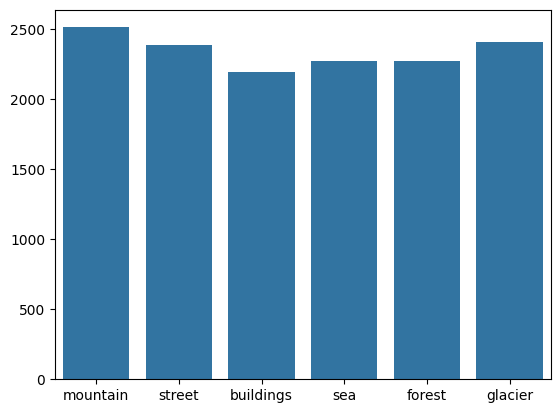

In [6]:
# class data size graph
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(class_count)
plt.show()

(150, 150, 3)
(150, 150, 3)
(150, 150, 3)
(150, 150, 3)
(150, 150, 3)
(150, 150, 3)


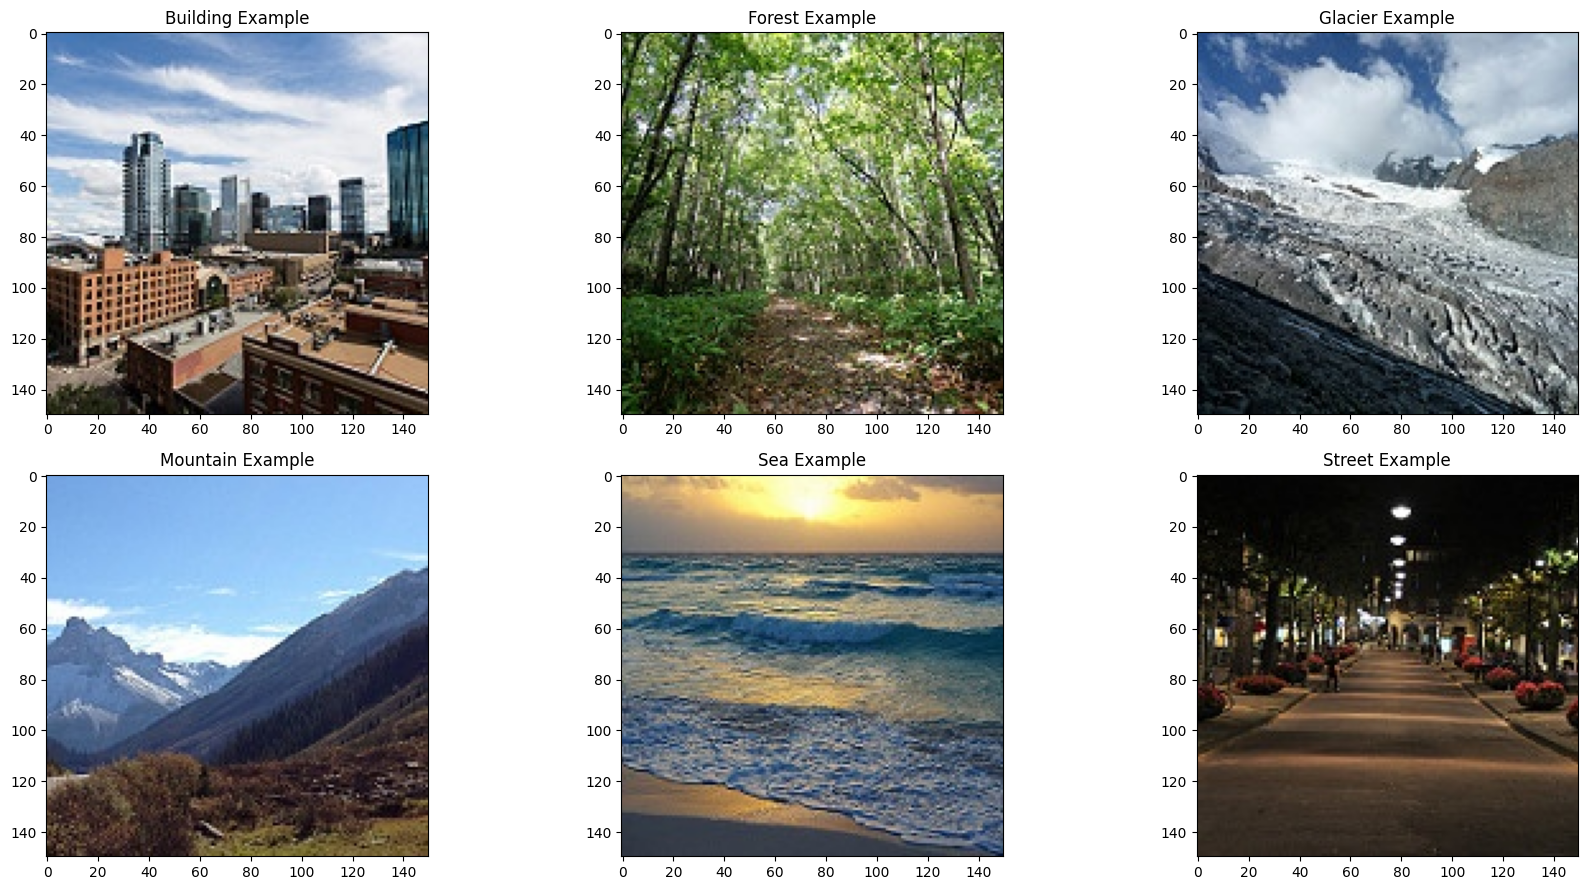

In [7]:
# example image data
plt.figure(figsize= (18,9))

plt.subplot(2, 3, 1)
img = plt.imread( f'{train_path}/buildings/10006.jpg' )
plt.imshow(img)
plt.title("Building Example")
print(img.shape)

plt.subplot(2, 3, 2)
img = plt.imread( f'{train_path}/forest/10010.jpg' )
plt.imshow(img)
plt.title("Forest Example")
print(img.shape)

plt.subplot(2, 3, 3)
img = plt.imread( f'{train_path}/glacier/10003.jpg' )
plt.imshow(img)
plt.title("Glacier Example")
print(img.shape)

plt.subplot(2, 3, 4)
img = plt.imread( f'{train_path}/mountain/10008.jpg' )
plt.imshow(img)
plt.title("Mountain Example")
print(img.shape)

plt.subplot(2, 3, 5)
img = plt.imread( f'{train_path}/sea/10041.jpg' )
plt.imshow(img)
plt.title("Sea Example")
print(img.shape)

plt.subplot(2, 3, 6)
img = plt.imread( f'{train_path}/street/10015.jpg' )
plt.imshow(img)
plt.title("Street Example")
print(img.shape)

plt.tight_layout()
plt.show()

classes are roughly balanced (~2,200–2,500 per class), all images are 150×150×3, no preprocessing surprises.

# DataLoaders

In [8]:
from torch.utils.data import DataLoader
trainloader = DataLoader(train_data , shuffle= True , batch_size=32)
testloader = DataLoader(test_data,shuffle = False , batch_size = 32)

# Model setup

In [9]:
from torchvision import models
import torch.nn as nn
import torch
model = models.resnet18(weights= models.ResNet18_Weights.IMAGENET1K_V1)

#### model adjusting for the mission

In [10]:
model.fc = nn.Linear(512,6)

In [11]:
model.eval()
model.requires_grad_(False)
model.layer4.train()
model.layer4.requires_grad_(True)
model.fc.train()
model.fc.requires_grad_(True)
model = model.to('cuda')

# Optimizer & loss function

In [12]:
optimizer = torch.optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3}
])
loss_function = nn.CrossEntropyLoss()

# Training loop with loss tracking

In [13]:
for epoch in range(5):
    for i , (images,labels) in enumerate(trainloader):
        images, labels = images.to('cuda'), labels.to('cuda')
        optimizer.zero_grad()
        output = model(images)
        loss = loss_function(output,labels)
        loss.backward()
        optimizer.step()
        if i % 200 == 0:
            print(f"Epoch {epoch}, Batch {i}, Loss: {loss}")

Epoch 0, Batch 0, Loss: 2.190505266189575
Epoch 0, Batch 200, Loss: 0.19822166860103607
Epoch 0, Batch 400, Loss: 0.17655017971992493
Epoch 1, Batch 0, Loss: 0.39296478033065796
Epoch 1, Batch 200, Loss: 0.33672797679901123
Epoch 1, Batch 400, Loss: 0.20483757555484772
Epoch 2, Batch 0, Loss: 0.14739234745502472
Epoch 2, Batch 200, Loss: 0.08642899990081787
Epoch 2, Batch 400, Loss: 0.28635507822036743
Epoch 3, Batch 0, Loss: 0.07967826724052429
Epoch 3, Batch 200, Loss: 0.09293967485427856
Epoch 3, Batch 400, Loss: 0.1065359115600586
Epoch 4, Batch 0, Loss: 0.06883122026920319
Epoch 4, Batch 200, Loss: 0.032930608838796616
Epoch 4, Batch 400, Loss: 0.05018794909119606


# Evaluation

In [19]:
model.eval()
predicted_labels = []
true_labels = []
with torch.no_grad():
    sum_images = 0
    sum_batch = 0
    sum_correct = 0
    for images, labels in testloader:
        images, labels = images.to('cuda'), labels.to('cuda')
        output = model(images)
        predicted = torch.argmax(output, dim=1)
        predicted_labels.extend(predicted.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

In [36]:
from sklearn.metrics import confusion_matrix , accuracy_score , classification_report
import seaborn as sns
import matplotlib.pyplot as plt

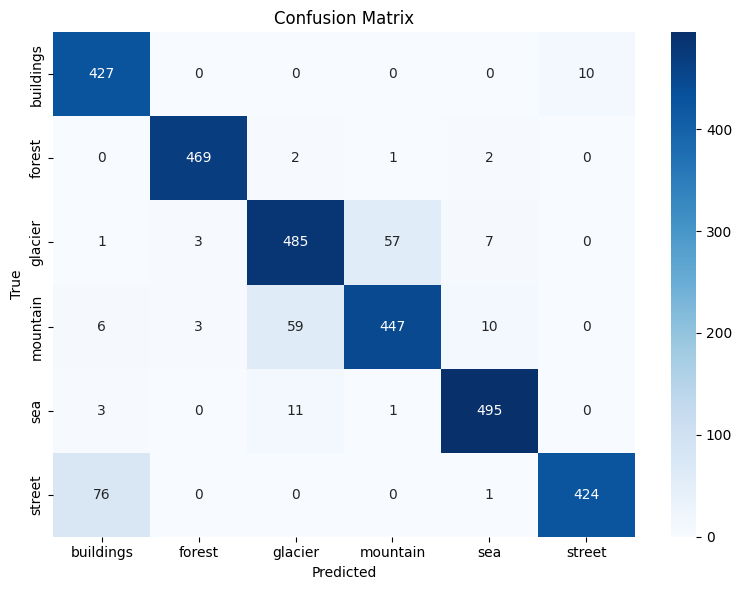

In [32]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=train_data.classes, yticklabels=train_data.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [37]:
print(classification_report(true_labels, predicted_labels, target_names=train_data.classes))

              precision    recall  f1-score   support

   buildings       0.83      0.98      0.90       437
      forest       0.99      0.99      0.99       474
     glacier       0.87      0.88      0.87       553
    mountain       0.88      0.85      0.87       525
         sea       0.96      0.97      0.97       510
      street       0.98      0.85      0.91       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



# Error Analysis

In [58]:
import numpy as np
predicted_labels = np.array(predicted_labels)
true_labels = np.array(true_labels)
wrong_indices = np.where(np.array(predicted_labels) != np.array(true_labels))[0]
print(len(wrong_indices))

253


[1667 2806 1412 2694 2382 1305]


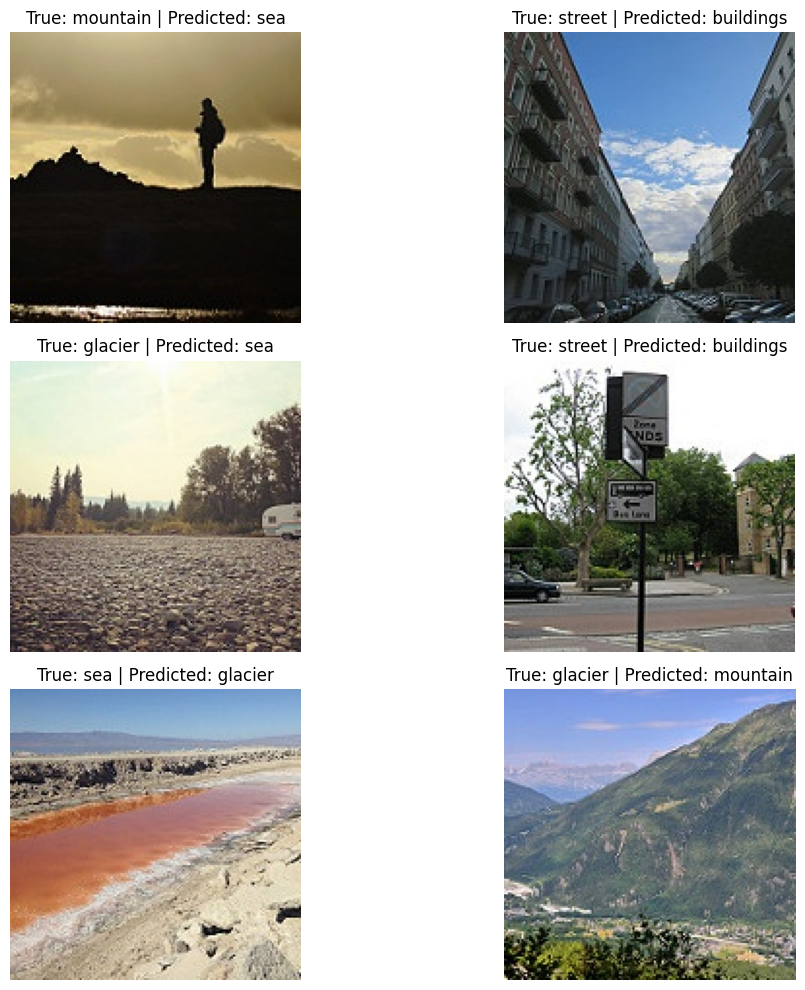

In [88]:
random_wrong = np.random.choice(wrong_indices, 6, replace=False)
print(random_wrong)
i = 1
plt.figure(figsize=(12, 10))
for idx in random_wrong:
    path = test_data.imgs[idx][0]
    plt.subplot(3 , 2 , i)
    i = i + 1
    plt.axis('off')
    plt.title(f"True: {test_data.classes[true_labels[idx]]} | Predicted: {test_data.classes[predicted_labels[idx]]}")
    plt.imshow(plt.imread(path))
plt.tight_layout()

# Conclusion
This project demonstrates image scene classification using transfer learning with a pretrained ResNet18 model on the Intel Image Classification dataset. By fine-tuning the last convolutional block (layer4) and the classifier head with discriminative learning rates, the model achieved 92% accuracy and 0.92 macro F1-score across 6 scene categories after just 5 epochs of training.
The model performs best on visually distinct classes like forest (99% F1) and sea (97% F1), while struggling most with glacier and mountain (both 87% F1). Error analysis reveals that most misclassifications occur between visually similar classes — glacier↔mountain (similar terrain and color palette) and buildings↔street (streets often contain buildings, creating label ambiguity). Many of the misclassified images are ambiguous even to human observers, suggesting that some errors reflect inherent overlap between categories rather than model weakness.
Possible improvements include using a larger backbone (ResNet50), training for more epochs with a learning rate scheduler, or applying more aggressive data augmentation to improve generalization on the harder classes.